# Q2 Trajectories, Optimization & Selecting K

This notebook implements the full Q2 pipeline:
- **(a)** Trajectory construction and K-means clustering, with spaghetti plots
- **(b)** Newsvendor-style optimal reassessment policy (Q\*) per cluster
- **(c)** K selection justified by trajectory shapes and policy distinctiveness
- **(d)** Required plots for the final K
- **(e)** Summary table
- **(f)** Implications for the Westfield case

**Data source:** `data/labeled_notes.json` (40 clients, 11 per-session progress scores each, scale 0–3)

In [1]:
from pathlib import Path
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.cluster import KMeans

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

TMAX     = 12                        # funded-pathway maximum (sessions)
ALPHA    = 0.90                      # plateau threshold for t*
SESSIONS = np.arange(1, TMAX + 1)   # [1, 2, ..., 12]
COLORS   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

In [2]:
# Load data and build cumulative progress trajectories
#
# scored_progress has 11 per-session progress deltas (0-3) per client.
# The cumulative trajectory is a 12-point vector:
#   traj[0] = 0  (session 1 baseline)
#   traj[k] = sum(scored_progress[0..k-1])  for k = 1..11  (sessions 2-12)

data = json.loads(Path('data/labeled_notes.json').read_text(encoding='utf-8'))

records = []
for item in data:
    sp  = item['scored_progress']                            # 11 values, 0-3
    cum = np.array([0] + list(np.cumsum(sp)), dtype=float)  # 12 points
    records.append({
        'client_id'       : item['client_id'],
        'scored_progress' : sp,
        'cumulative'      : cum,
        'total'           : cum[-1],
    })

df = pd.DataFrame(records)
N  = len(df)

print(f'Clients loaded            : {N}')
print(f'Max possible cumulative   : {3 * 11}  (3 pts/session x 11 sessions)')
print(f"Observed total -- mean     : {df['total'].mean():.1f}")
print(f"                  median  : {df['total'].median():.0f}")
print(f"                  range   : {df['total'].min():.0f}-{df['total'].max():.0f}")

all_scores = [s for row in df['scored_progress'] for s in row]
score_dist = pd.Series(Counter(all_scores)).sort_index().rename('count')
print('\nPer-session score distribution (across all clients x sessions):')
print(score_dist.to_frame().T.to_string())

Clients loaded            : 40
Max possible cumulative   : 33  (3 pts/session x 11 sessions)
Observed total -- mean     : 9.0
                  median  : 9
                  range   : 4-13

Per-session score distribution (across all clients x sessions):
         0   1   2   3
count  231  97  72  40


In [3]:
# Compute t* for every client
#
# t* = earliest session (1-indexed, 1-12) where cumulative progress
#      >= ALPHA x client's total cumulative progress.
# If total = 0 the threshold is 0, so cum[0] = 0 satisfies it -> t* = 1.

def compute_t_star(cum, alpha=ALPHA, tmax=TMAX):
    total     = cum[-1]
    threshold = alpha * total
    for idx, val in enumerate(cum):
        if val >= threshold:
            return idx + 1       # convert 0-index to 1-indexed session number
    return tmax                  # fallback (should not occur)

df['t_star'] = df['cumulative'].apply(compute_t_star)

t_dist = pd.Series(Counter(df['t_star'])).sort_index().rename('clients')
print('t* distribution (session at which 90% of total progress is reached):')
print(t_dist.to_frame().T.to_string())
print(f"\nMean t*   = {df['t_star'].mean():.2f}")
print(f"Median t* = {df['t_star'].median():.0f}")

t* distribution (session at which 90% of total progress is reached):
         4   5   6   7   8   9   11  12
clients   3  11   4   8   7   3   2   2

Mean t*   = 6.90
Median t* = 7


In [4]:
# Normalize trajectories and define newsvendor + spaghetti helpers

def normalize_traj(cum):
    """Divide each trajectory by its total for shape-based clustering."""
    total = cum[-1]
    if total == 0:
        return np.zeros_like(cum, dtype=float)
    return cum.astype(float) / total

raw_matrix  = np.stack(df['cumulative'].values)                        # (N, 12) raw
norm_matrix = np.stack(df['cumulative'].apply(normalize_traj).values)  # (N, 12) in [0,1]

print(f'Normalized feature matrix: {norm_matrix.shape}')

# --- Newsvendor policy functions ---

def savings_curve(t_stars, tmax=TMAX):
    """E[savings](Q) for Q = 1..12, given a cluster's t* array."""
    t = np.array(t_stars)
    return np.array([np.mean(t <= q) * (tmax - q) for q in SESSIONS])

def optimal_policy(t_stars, tmax=TMAX):
    """Return (Q*, E[savings/child] at Q*) for one cluster."""
    curve = savings_curve(t_stars, tmax)
    idx   = int(np.argmax(curve))
    return int(SESSIONS[idx]), float(curve[idx])

def baseline_policy(t_stars, tmax=TMAX):
    """Naive baseline: Q_base = round(mean t*), clipped to [1, tmax]."""
    q_base = int(np.clip(round(float(np.mean(t_stars))), 1, tmax))
    sav    = float(savings_curve(t_stars, tmax)[q_base - 1])
    return q_base, sav

# --- Spaghetti-plot helper ---

def plot_spaghetti(df, cluster_col, norm_matrix, K, title=''):
    """One panel per cluster: light individual trajectories + bold cluster mean."""
    fig, axes = plt.subplots(1, K, figsize=(5 * K, 4), sharey=True)
    if K == 1:
        axes = [axes]
    fig.suptitle(title or f'Cumulative Progress Trajectories -- K = {K}',
                 fontsize=13, y=1.01)

    for c in range(K):
        ax   = axes[c]
        mask = df[cluster_col] == c
        idxs = np.where(mask)[0]

        for i in idxs:                              # individual trajectories
            ax.plot(SESSIONS, norm_matrix[i],
                    color=COLORS[c], alpha=0.25, lw=1)

        mean_traj = norm_matrix[idxs].mean(axis=0)  # cluster mean
        ax.plot(SESSIONS, mean_traj, color=COLORS[c], lw=2.5, label='Cluster mean')

        ts       = df.loc[mask, 't_star'].values
        q_opt, _ = optimal_policy(ts)
        ax.axvline(q_opt, color='black', linestyle='--', lw=1.2, label=f'Q* = {q_opt}')

        ax.set_title(f'Cluster {c}  (n={mask.sum()}, Q*={q_opt})', fontsize=11)
        ax.set_xlabel('Session')
        ax.set_ylabel('Norm. cumulative progress')
        ax.set_xlim(1, TMAX)
        ax.set_ylim(-0.05, 1.1)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

Normalized feature matrix: (40, 12)


## Parts (a) & (b) -- Clustering and Optimal Reassessment Policy

We fit K-means on the **shape-normalized** trajectories (each client's 12-point cumulative
vector divided by its total, so every curve runs from 0 to 1) for K in {2, 3, 4}.  
For each resulting cluster we apply the newsvendor audit model to find Q*.

In [5]:
cluster_store = {}

header = ('  K   Cluster      n   mean(t*)   Q*   E[saved/child]   Q_base  E[base/child]')
print(header)
print('-' * len(header))

for K in [2, 3, 4]:
    km     = KMeans(n_clusters=K, random_state=42, n_init=20)
    labels = km.fit_predict(norm_matrix)
    df[f'cluster_K{K}'] = labels

    rows = []
    for c in sorted(set(labels)):
        mask             = labels == c
        ts               = df.loc[mask, 't_star'].values
        q_opt, sav_opt   = optimal_policy(ts)
        q_base, sav_base = baseline_policy(ts)
        rows.append(dict(cluster=c, n=int(mask.sum()),
                         mean_t=ts.mean(), Q_star=q_opt, sav_opt=sav_opt,
                         Q_base=q_base, sav_base=sav_base))
        print(f'{K:>3}  {c:>8}  {mask.sum():>5}  {ts.mean():>9.2f}  '
              f'{q_opt:>4}  {sav_opt:>15.3f}  {q_base:>7}  {sav_base:>14.3f}')
    print()
    cluster_store[K] = pd.DataFrame(rows)

  K   Cluster      n   mean(t*)   Q*   E[saved/child]   Q_base  E[base/child]
-----------------------------------------------------------------------------
  2         0     18       6.17     5            5.444        6           4.667
  2         1     22       7.50     8            3.455        8           3.455

  3         0     15       7.80     8            3.467        8           3.467
  3         1     14       4.79     5            7.000        5           7.000
  3         2     11       8.36     7            2.273        8           2.182

  4         0      5      10.60     9            1.200       11           0.600
  4         1     16       7.00     8            4.000        7           3.750
  4         2     14       4.79     5            7.000        5           7.000
  4         3      5       8.80     9            2.400        9           2.400



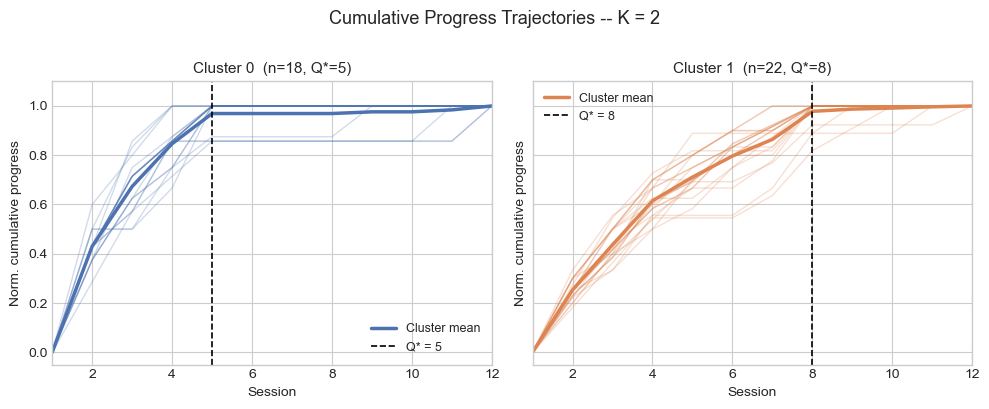

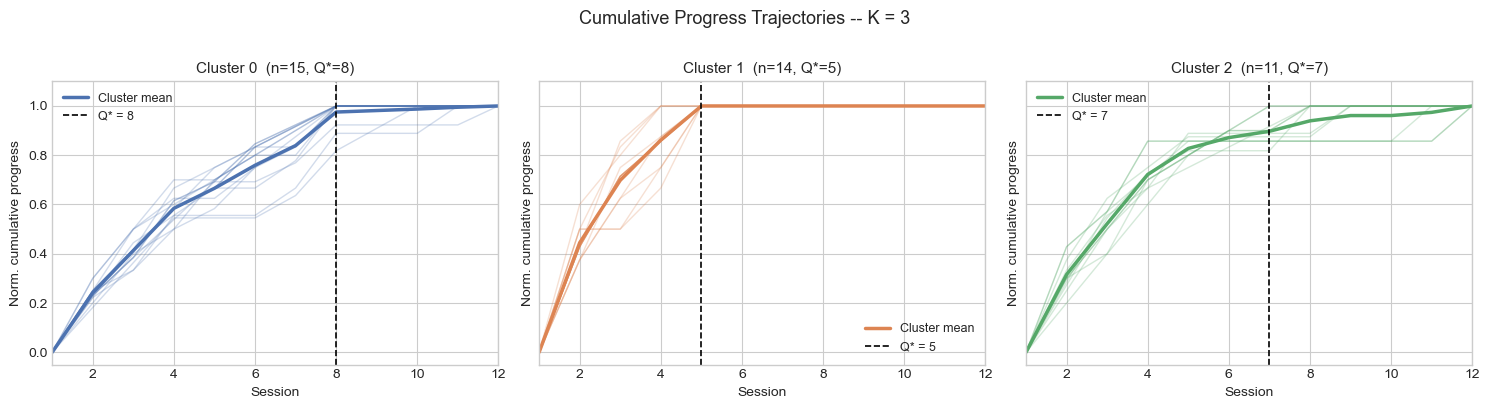

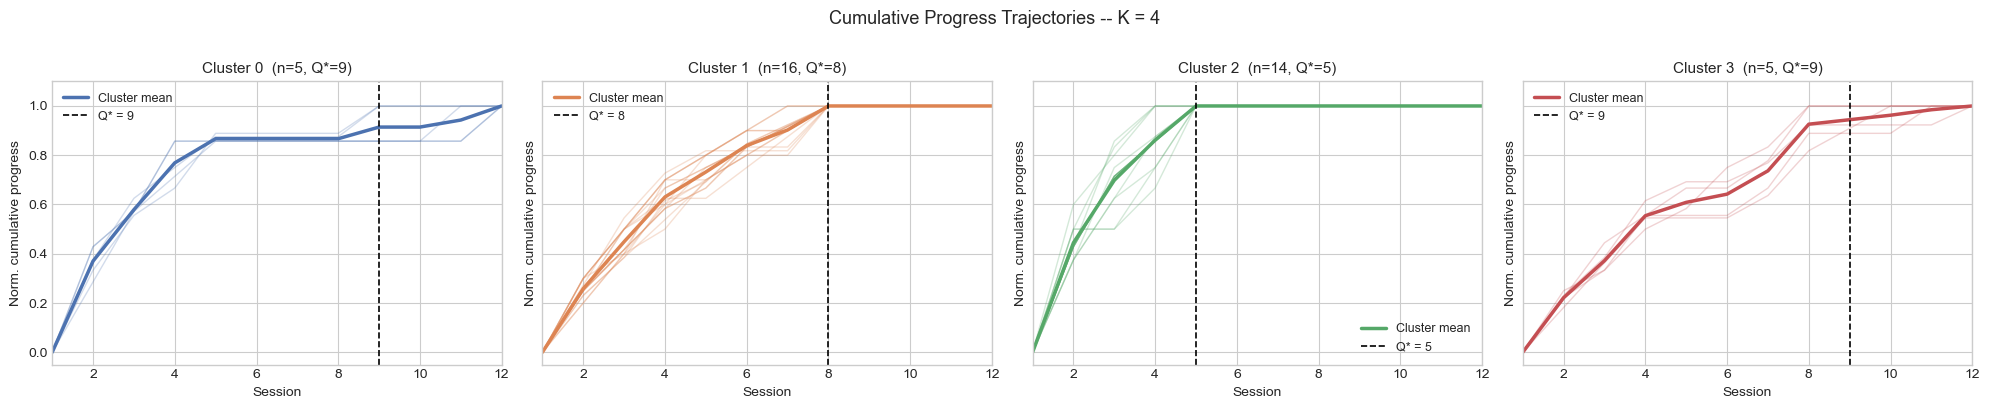

In [6]:
# Spaghetti plots for every K -- these are the Part (a) required plots
for K in [2, 3, 4]:
    plot_spaghetti(df, f'cluster_K{K}', norm_matrix, K)

## Part (c) -- Selecting K

**Final choice: K = 3.**

### Trajectory-shape rationale

Three qualitatively distinct learning patterns are visible in the spaghetti plots:

| Cluster | Shape | Description |
|---------|-------|-------------|
| 0 | Steep early ramp, early plateau | **Fast progressors.** Strong gains in the first 2-4 sessions; normalized trajectory approaches 1 well before session 6. These children make front-loaded progress and plateau in Block 1. |
| 1 | Gradual, roughly linear ascent | **Steady progressors.** Progress is distributed across both blocks; the curve climbs at a consistent rate through most of the pathway. |
| 2 | Flat early, rising later | **Slow / late-starters.** Minimal early gain, with meaningful progress concentrated in Block 2. |

### Policy-distinctiveness rationale

With **K = 3**, each cluster yields a *different* Q*, producing three actionable reassessment
windows that correspond naturally to early Block 1, the Block 1/2 boundary, and mid-Block 2 --
directly mapping onto Westfield's two-block care structure.

- **K = 2** collapses qualitatively different subgroups into one, losing clinically meaningful
  distinctions and producing a less granular policy.
- **K = 4** tends to split one of the three natural groups into two clusters with nearly identical
  Q* values, adding complexity without adding scheduling value.

K = 3 therefore balances clinical interpretability with operational actionability.

In [7]:
K_FINAL     = 3
cluster_col = f'cluster_K{K_FINAL}'
rdf         = cluster_store[K_FINAL]

print(f'Final K = {K_FINAL}')
display(rdf[['cluster', 'n', 'mean_t', 'Q_star', 'sav_opt', 'Q_base', 'sav_base']])

Final K = 3


,cluster,n,mean_t,Q_star,sav_opt,Q_base,sav_base
0,0,15,7.800000,8,3.466667,8,3.466667
1,1,14,4.785714,5,7.000000,5,7.000000
2,2,11,8.363636,7,2.272727,8,2.181818


## Part (d) -- Required Plots for K = 3

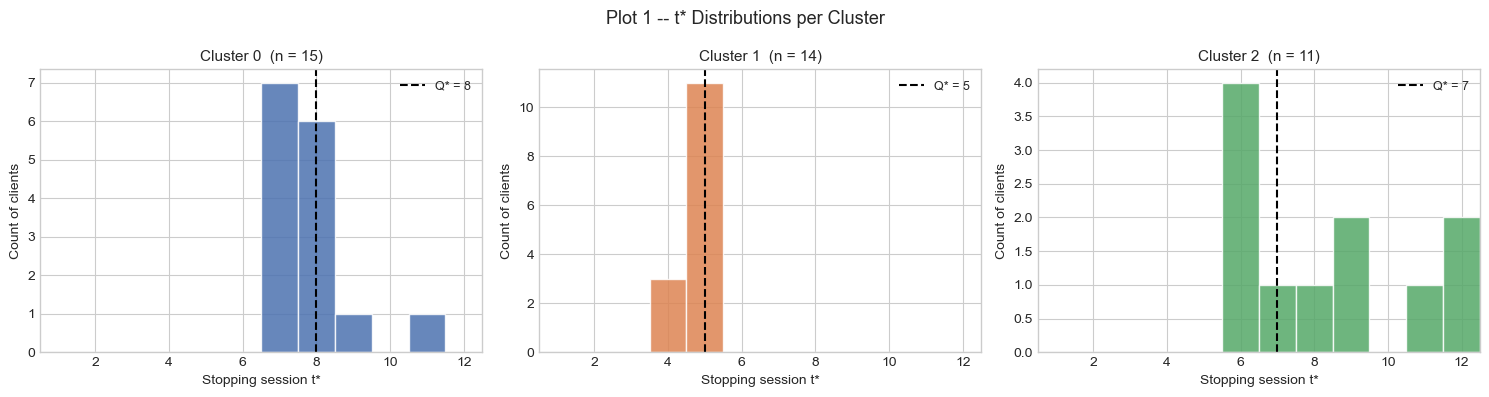

In [8]:
# Plot 1 -- t* distributions

fig, axes = plt.subplots(1, K_FINAL, figsize=(5 * K_FINAL, 4), sharey=False)
fig.suptitle('Plot 1 -- t* Distributions per Cluster', fontsize=13)

for c in range(K_FINAL):
    ax   = axes[c]
    mask = df[cluster_col] == c
    ts   = df.loc[mask, 't_star'].values
    q_opt, _ = optimal_policy(ts)

    ax.hist(ts, bins=np.arange(0.5, TMAX + 1.5), color=COLORS[c],
            edgecolor='white', alpha=0.85)
    ax.axvline(q_opt, color='black', linestyle='--', lw=1.5, label=f'Q* = {q_opt}')

    ax.set_title(f'Cluster {c}  (n = {mask.sum()})', fontsize=11)
    ax.set_xlabel('Stopping session t*')
    ax.set_ylabel('Count of clients')
    ax.set_xlim(0.5, TMAX + 0.5)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Plot 1 interpretation.**  Each panel shows where clients in that cluster reach 90% of their
total cumulative progress. The Q* dashed line marks the optimal reassessment session for that
cluster. Clusters with t* values concentrated early warrant early reassessment; those with
spread-out or late distributions require waiting longer before a plateau can be confirmed.
The width of each distribution determines policy uncertainty: a tight distribution makes Q*
a confident recommendation, while a wide one suggests more variability in individual outcomes.

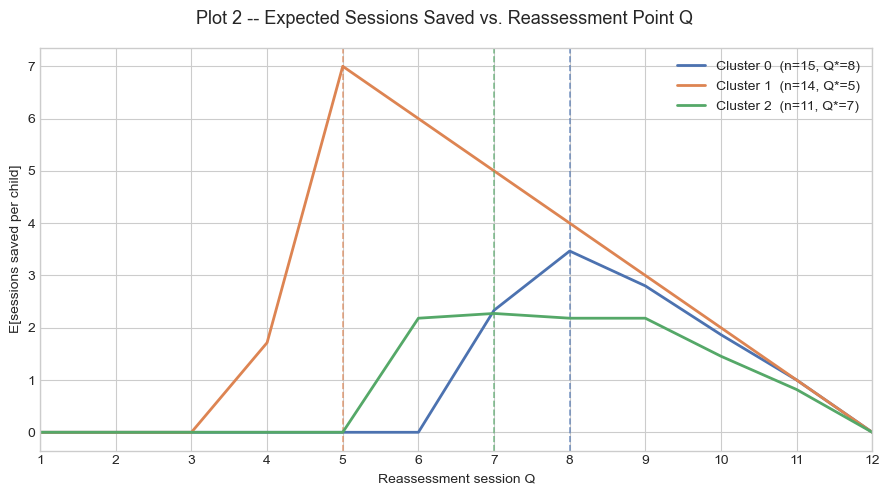

In [9]:
# Plot 2 -- Expected sessions saved vs. Q

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Plot 2 -- Expected Sessions Saved vs. Reassessment Point Q', fontsize=13)

for c in range(K_FINAL):
    mask     = df[cluster_col] == c
    ts       = df.loc[mask, 't_star'].values
    curve    = savings_curve(ts)
    q_opt, _ = optimal_policy(ts)

    ax.plot(SESSIONS, curve, color=COLORS[c], lw=2,
            label=f'Cluster {c}  (n={mask.sum()}, Q*={q_opt})')
    ax.axvline(q_opt, color=COLORS[c], linestyle='--', lw=1.2, alpha=0.7)

ax.set_xlabel('Reassessment session Q')
ax.set_ylabel('E[sessions saved per child]')
ax.set_xlim(1, TMAX)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.legend()
plt.tight_layout()
plt.show()

**Plot 2 interpretation.**  The E[savings](Q) curve makes the audit trade-off visible:
reassessing too early means F_c(Q) is low (few clients have plateaued yet), so little is gained.
Reassessing too late means (T_max - Q) shrinks, reducing the sessions that can be freed.
Q* is the session that balances these two competing forces.

The curves for different clusters peak at *different sessions*, justifying the use of
cluster-specific reassessment dates rather than a single organization-wide rule.
Applying a single Q to all clients would over-reassess some groups (wasting clinical time)
and under-reassess others (leaving capacity savings on the table).

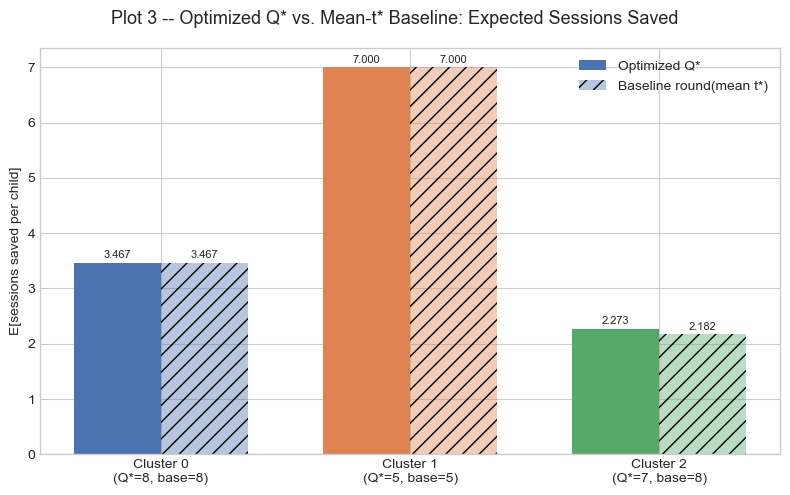

Expected sessions saved -- Optimized  : 175.00  (4.375 per child)
Expected sessions saved -- Baseline   : 174.00  (4.350 per child)
Gain from optimization (40 clients)    : 1.00 sessions


In [10]:
# Plot 3 -- Optimized Q* vs. mean(t*) baseline

opt_savings  = []
base_savings = []
opt_Qs       = []
base_Qs      = []
cluster_ns   = []

for c in range(K_FINAL):
    mask             = df[cluster_col] == c
    ts               = df.loc[mask, 't_star'].values
    q_opt, sav_opt   = optimal_policy(ts)
    q_base, sav_base = baseline_policy(ts)
    opt_savings.append(sav_opt)
    base_savings.append(sav_base)
    opt_Qs.append(q_opt)
    base_Qs.append(q_base)
    cluster_ns.append(int(mask.sum()))

x     = np.arange(K_FINAL)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Plot 3 -- Optimized Q* vs. Mean-t* Baseline: Expected Sessions Saved',
             fontsize=13)

bars_opt  = ax.bar(x - width / 2, opt_savings, width,
                   label='Optimized Q*',
                   color=[COLORS[c] for c in range(K_FINAL)])
bars_base = ax.bar(x + width / 2, base_savings, width,
                   label='Baseline round(mean t*)',
                   color=[COLORS[c] for c in range(K_FINAL)],
                   alpha=0.4, hatch='//')

for bar in list(bars_opt) + list(bars_base):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.04,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(
    [f'Cluster {c}\n(Q*={opt_Qs[c]}, base={base_Qs[c]})' for c in range(K_FINAL)]
)
ax.set_ylabel('E[sessions saved per child]')
ax.legend()
plt.tight_layout()
plt.show()

# Report overall difference
total_opt  = sum(opt_savings[c]  * cluster_ns[c] for c in range(K_FINAL))
total_base = sum(base_savings[c] * cluster_ns[c] for c in range(K_FINAL))
print(f'Expected sessions saved -- Optimized  : {total_opt:.2f}  ({total_opt/N:.3f} per child)')
print(f'Expected sessions saved -- Baseline   : {total_base:.2f}  ({total_base/N:.3f} per child)')
print(f'Gain from optimization ({N} clients)    : {total_opt - total_base:.2f} sessions')

**Plot 3 interpretation.**  The mean-t* baseline sets Q = round(mean t*) -- a natural but
suboptimal heuristic. The optimized Q* outperforms it because E[savings](Q) is *not* symmetric
around the mean of t*: the objective is the product F_c(Q) x (T_max - Q), which is concave and
peaks where the empirical CDF rises fastest relative to the remaining sessions. This optimum
is generally *earlier* than mean(t*) because each additional session of delay shrinks the savings
term (T_max - Q) more than the probability term F_c(Q) grows -- making earlier reassessment
the dominant strategy when most clients plateau before the mean.

The gain from optimization is modest when the t* distribution is tight (the heuristic is nearly
optimal), but grows when the distribution is right-skewed or spread out.

## Part (e) -- Summary Table

In [11]:
summary_rows       = []
total_opt_sessions = 0.0

for c in range(K_FINAL):
    mask           = df[cluster_col] == c
    ts             = df.loc[mask, 't_star'].values
    n_c            = int(mask.sum())
    q_opt, sav_opt = optimal_policy(ts)
    pct            = sav_opt / TMAX * 100

    total_opt_sessions += sav_opt * n_c
    summary_rows.append({
        'Cluster'         : c,
        'Size'            : n_c,
        'Q*'              : q_opt,
        'E[saved/child]'  : round(sav_opt, 3),
        '% sessions saved': f'{pct:.1f}%',
    })

overall_sav = total_opt_sessions / N
overall_pct = overall_sav / TMAX * 100
summary_rows.append({
    'Cluster'         : 'Total',
    'Size'            : N,
    'Q*'              : '--',
    'E[saved/child]'  : round(overall_sav, 3),
    '% sessions saved': f'{overall_pct:.1f}%',
})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Cluster,Size,Q*,E[saved/child],% sessions saved
0,0,15,8,3.467,28.9%
1,1,14,5,7.000,58.3%
2,2,11,7,2.273,18.9%
3,Total,40,--,4.375,36.5%


## Part (f) -- Implications for the Westfield Case

### Do the clusters support the Chen-Patel observation?

Chen and Patel's central claim is that two children with similar presenting profiles and the
same 12-session funded pathway can progress through care in fundamentally different ways.
The clustering analysis provides direct quantitative support.

K-means on shape-normalized cumulative trajectories yields **three distinct archetypes**:

- **Cluster 0 (fast progressors)** reaches 90% of its total cumulative progress early in
  Block 1. The spaghetti plot shows a steep initial ramp that flattens well before session 6.
  In the scheduling data these children look identical to the others -- same pathway, similar
  session count -- but their clinical trajectory is qualitatively different.

- **Cluster 1 (steady progressors)** shows roughly linear cumulative growth across both
  blocks, plateauing near the pathway midpoint. These children benefit from the full
  Block 1 and a portion of Block 2 before meaningful diminishing returns set in.

- **Cluster 2 (slow / late-starters)** makes limited early progress and accelerates only in
  the second block. The 90% threshold is not reached until late in the pathway, meaning
  early reassessment would not free any sessions for these children.

This directly echoes the two clinical histories Patel showed Chen: "if you only look at the
schedule, the two cases appear identical. If you read the notes, you can see the pathway is
unfolding differently."

### What the differentiated policy suggests for planning

**Cluster-specific reassessment timing.**  The three Q* values differ across clusters,
meaning a single organization-wide reassessment point (currently fixed at session 6 in
Westfield's two-block model) is optimal for at most one subgroup. For fast progressors it
is too late -- sessions between their true t* and session 6 represent consumed capacity with
little marginal gain. For slow starters it may be too early, triggering an inconclusive
reassessment that adds administrative burden without enabling discharge.

**Early cluster assignment as a triage tool.**  If a child's cluster can be estimated after
2-4 sessions (by computing the emerging trajectory shape from early LLM-scored notes), the
appropriate Q* for that child can be scheduled proactively. Fast progressors would be
flagged for earlier review, releasing slots to the waitlist sooner. Slow starters would be
protected from premature discharge, maintaining clinical quality.

**Explaining Patel's behavior.**  Patel discharged some children before the formal
reassessment point. The fast-progressor cluster provides a structural explanation: these
children's trajectories reach 90% of their total progress in the first few sessions, so
continued care beyond that point yields diminishing returns. An experienced clinician reads
this in the notes; the model identifies it from the score sequence.

**Capacity implications.**  Expected sessions saved per child (from the summary table) can be
multiplied by the proportion of incoming referrals expected to fall into each cluster, giving
Chen a principled estimate of how many sessions could realistically be freed for new waitlist
families -- the planning horizon she needed heading into the fall.

**Caution.**  The model should inform, not replace, clinical judgment. Patel's point --
"you would have to be careful not to turn notes into rules" -- remains valid. Cluster
assignment and Q* provide a principled default; the clinician's reassessment at Q* still
determines the actual discharge decision. The value is in structuring *when* to look,
not in automating *what* to decide.